In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/riyadh-hospital-admissions-dataset-20202024/Hospital_Dataset_2020_2024.csv")
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   admission_date             41544 non-null  object 
 1   hospital_name              41544 non-null  object 
 2   admission_count            41544 non-null  int64  
 3   condition_type             41544 non-null  object 
 4   patient_age_group          41544 non-null  object 
 5   patient_gender             41544 non-null  object 
 6   readmission_count          41544 non-null  int64  
 7   severity_level             41544 non-null  object 
 8   length_of_stay_avg         41544 non-null  float64
 9   seasonal_indicator         41544 non-null  object 
 10  comorbid_conditions_count  41544 non-null  int64  
 11  primary_diagnosis_code     41544 non-null  object 
 12  daily_medication_dosage    41544 non-null  float64
 13  emergency_visit_count      41544 non-null  int

In [2]:
print(df.isna().sum())
print(df.dtypes)


admission_date               0
hospital_name                0
admission_count              0
condition_type               0
patient_age_group            0
patient_gender               0
readmission_count            0
severity_level               0
length_of_stay_avg           0
seasonal_indicator           0
comorbid_conditions_count    0
primary_diagnosis_code       0
daily_medication_dosage      0
emergency_visit_count        0
dtype: int64
admission_date                object
hospital_name                 object
admission_count                int64
condition_type                object
patient_age_group             object
patient_gender                object
readmission_count              int64
severity_level                object
length_of_stay_avg           float64
seasonal_indicator            object
comorbid_conditions_count      int64
primary_diagnosis_code        object
daily_medication_dosage      float64
emergency_visit_count          int64
dtype: object


In [3]:
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['Month'] = df['admission_date'].dt.to_period('M')

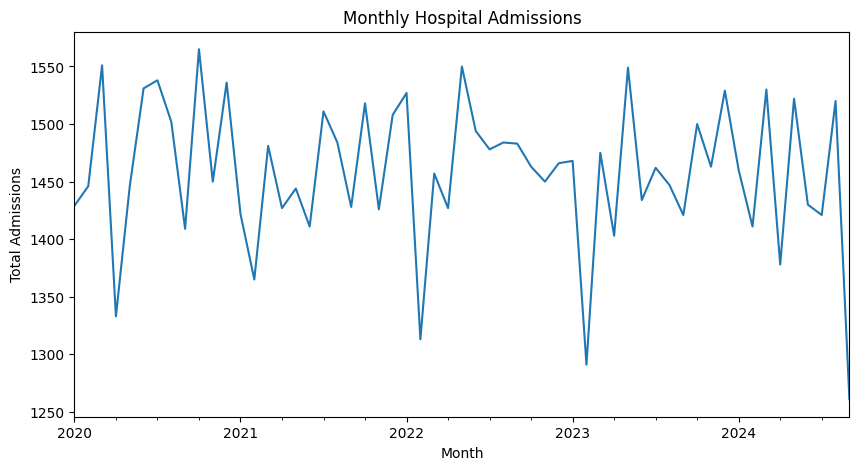

In [4]:
monthly_adm = df.groupby('Month')['admission_count'].sum()

plt.figure(figsize=(10,5))
monthly_adm.plot()
plt.title("Monthly Hospital Admissions")
plt.xlabel("Month")
plt.ylabel("Total Admissions")
plt.show()

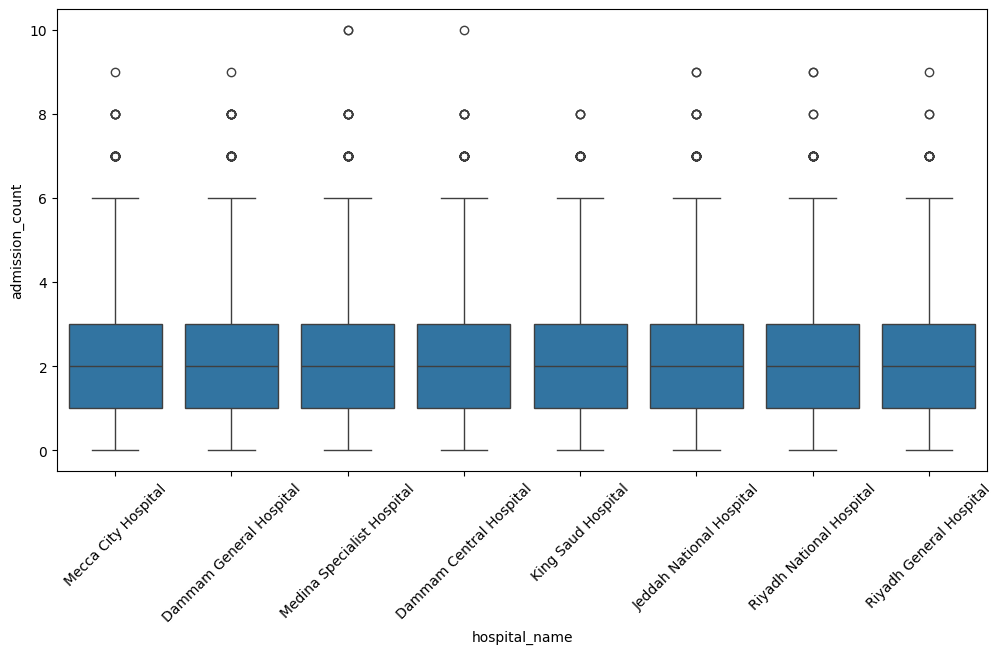

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(x='hospital_name', y='admission_count', data=df)
plt.xticks(rotation=45)
plt.show()


In [6]:
from scipy.stats import f_oneway

groups = [group['admission_count'].values for name, group in df.groupby('hospital_name')]

f_stat, p_val = f_oneway(*groups)
print("F-statistic:", f_stat)
print("p-value:", p_val)


F-statistic: 0.7349478770769863
p-value: 0.6423188943825104


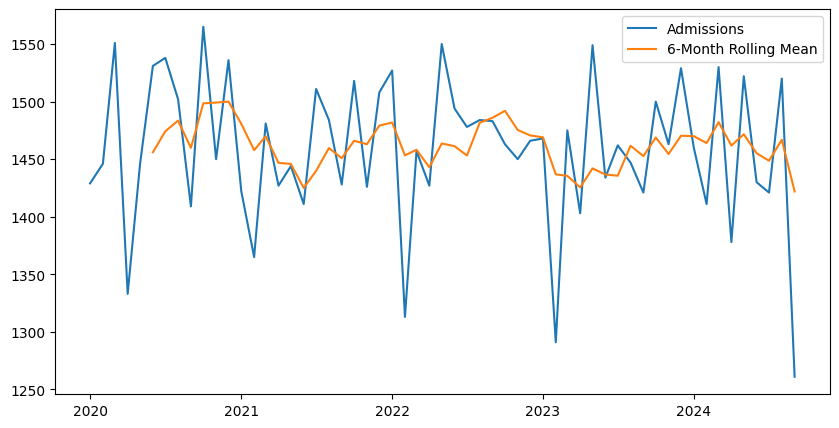

In [7]:
ts = monthly_adm.to_timestamp()
roll = ts.rolling(window=6).mean()

plt.figure(figsize=(10,5))
plt.plot(ts, label='Admissions')
plt.plot(roll, label='6-Month Rolling Mean')
plt.legend()
plt.show()


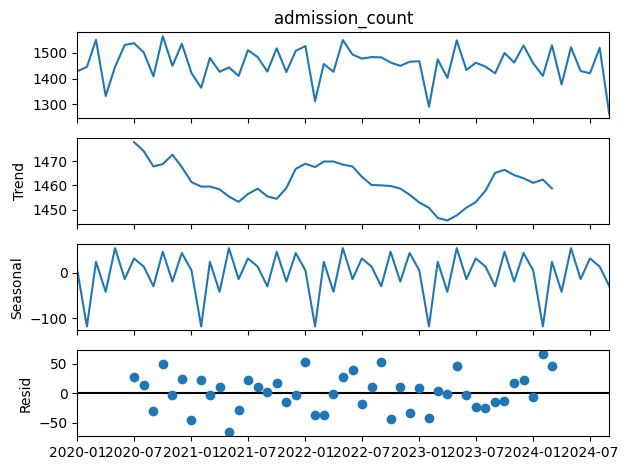

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(ts, model='additive')
decomp.plot()
plt.show()


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df[['length_of_stay_avg', 'emergency_visit_count']]
y = df['admission_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)


RMSE: 1.4311620683739512
R² Score: -0.00011218214831076878
